**Importing Libraries and creating dataset**

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#creating dataset
# Create dataset directly (no CSV needed)
data = pd.DataFrame({
    'area': [850,900,1200,1500,1800,2000,2200,2500,2700,3000,
             1100,1300,1600,1900,2100,2300,2600,2800,3100,3300],
    'bedrooms': [2,2,3,3,4,4,5,5,4,5,
                 2,3,3,4,4,5,5,4,5,5],
    'location_score': [6,7,8,9,9,10,9,10,8,10,
                       7,7,8,9,9,10,9,8,10,10],
    'price': [120000,135000,200000,250000,320000,400000,450000,500000,420000,550000,
              160000,210000,260000,330000,370000,480000,520000,430000,580000,620000]
})

# View dataset
print(data.head())

   area  bedrooms  location_score   price
0   850         2               6  120000
1   900         2               7  135000
2  1200         3               8  200000
3  1500         3               9  250000
4  1800         4               9  320000


**Data Processing**

In [23]:
#selection features input/features and output/target
X=data[['area','bedrooms','location_score']]
y=data['price']
X_train, X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#Scaling features
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

**Building the Neural Network Model**

In [24]:
#creating model
model=Sequential()
#input(hidden layers)
model.add(Dense(64,activation='relu',input_shape=(X_train.shape[1],)))
model.add(Dense(32,activation='relu'))
#output layer
model.add(Dense(1))
#compiling (MSE for regression)
model.compile(optimizer='adam',loss='mean_squared_error', metrics=['mae'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Training the Model**

In [25]:
#Training model
history= model.fit(X_train,y_train,epochs=100,batch_size=11, validation_split=0.1)


Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 233ms/step - loss: 166514393088.0000 - mae: 380000.2188 - val_loss: 169699999744.0000 - val_mae: 410000.0000
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 166514311168.0000 - mae: 380000.0625 - val_loss: 169699966976.0000 - val_mae: 409999.9688
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 166514245632.0000 - mae: 380000.0000 - val_loss: 169699950592.0000 - val_mae: 409999.9375
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 166514180096.0000 - mae: 379999.8438 - val_loss: 169699901440.0000 - val_mae: 409999.8750
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 166514114560.0000 - mae: 379999.7812 - val_loss: 169699901440.0000 - val_mae: 409999.8750
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 166514032640.0000 - mae: 379999.6875 - val_loss: 169699852288.0000 - val_mae: 409999.8125
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 166513967104.0000 - mae: 379999.5625 - val_loss: 169

**Evaluating the Model**

In [26]:
#predicting on the test data
y_pred= model.predict(X_test)
#calculating mean square error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error: ", mse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Mean Squared Error:  111934447616.0


**Plotting Graph**

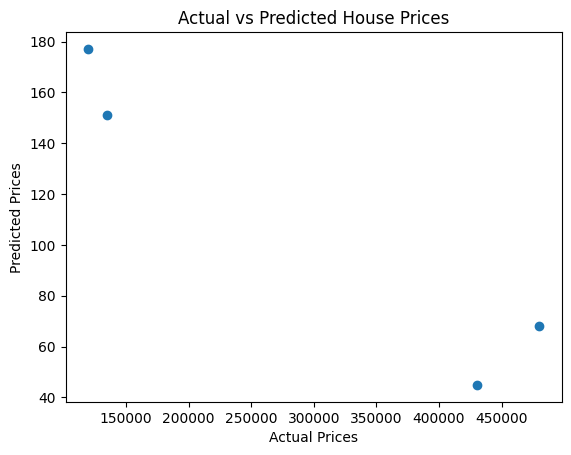

In [27]:
#plot comparision
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()